


# **Online Retail Analysis**

In [30]:
from datetime import datetime, timedelta
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 04/21/26 23:38:49


# Data Cleaning

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_excel('/content/drive/MyDrive/Projects/Online Retail.xlsx')

In [7]:
df.shape

(541909, 8)

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df.shape

(406829, 8)

In [12]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


'In this section I remove cancelled orders identified by invoices starting with 'C'''

In [13]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

"I create a Revenue column by multiplying Quantity by Unitprice to enable sales analysis"

In [14]:
df['Revenue'] = df['UnitPrice'] * df['Quantity']

In [15]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


# Exploratory Data Analysis

# **Which countries generate the most revenue?**

In [16]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

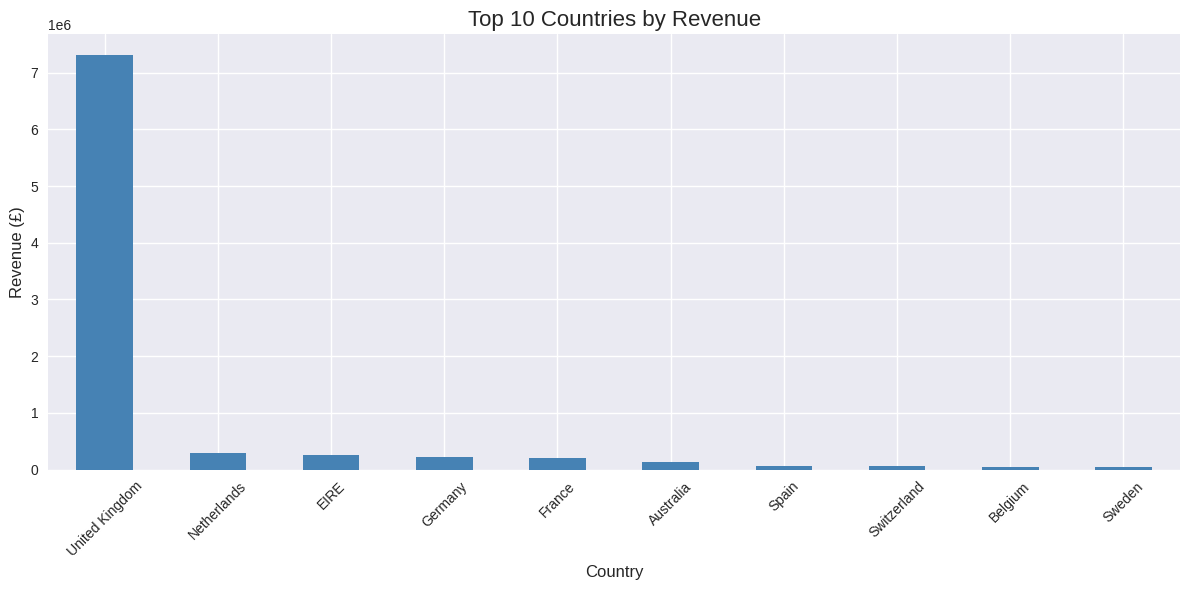

In [17]:
plt.figure(figsize=(12,6))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Revenue', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The UK accounts for the majority of total revenue, generating over £7 million, which is significantly more than all other countries combines. This makes sense as th eretailer is UK-based. Netherlands and EIRE (Ireland) are the top international markets.

# **Which products generate the most revenue?**



> Add blockquote



In [18]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

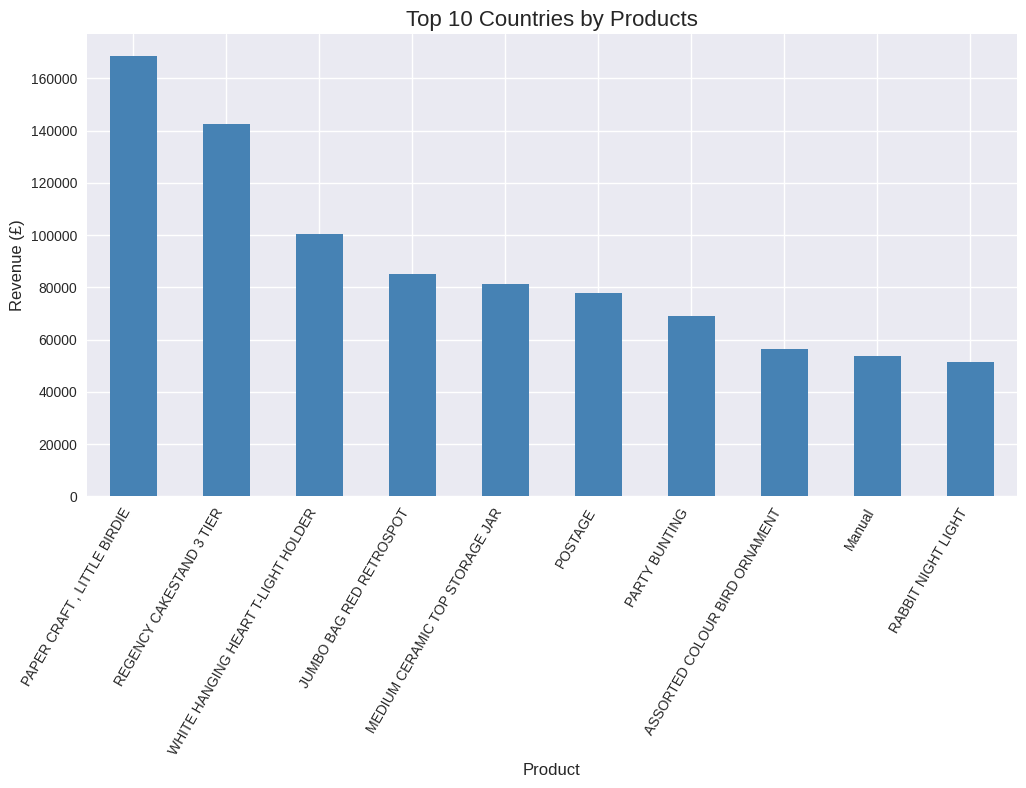

<Figure size 1800x700 with 0 Axes>

In [19]:
plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Products', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=60, ha = 'right')
plt.figure(figsize=(18,7))
plt.tight_layout()
plt.show()


PAPER CRAFT LITTLE BIRDIE stands out as the highest revenue-generating product, followed by decorative and gift items. This indicates that novelty décor and gift products are key drivers of sales, with demand likely increasing during peak seasons like holidays

# **Do sales spike during certain months or seasons?**

In [21]:
# Montly revenue trend to identify seasonla patterns
df['Month'] = df['InvoiceDate'].dt.month

In [22]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

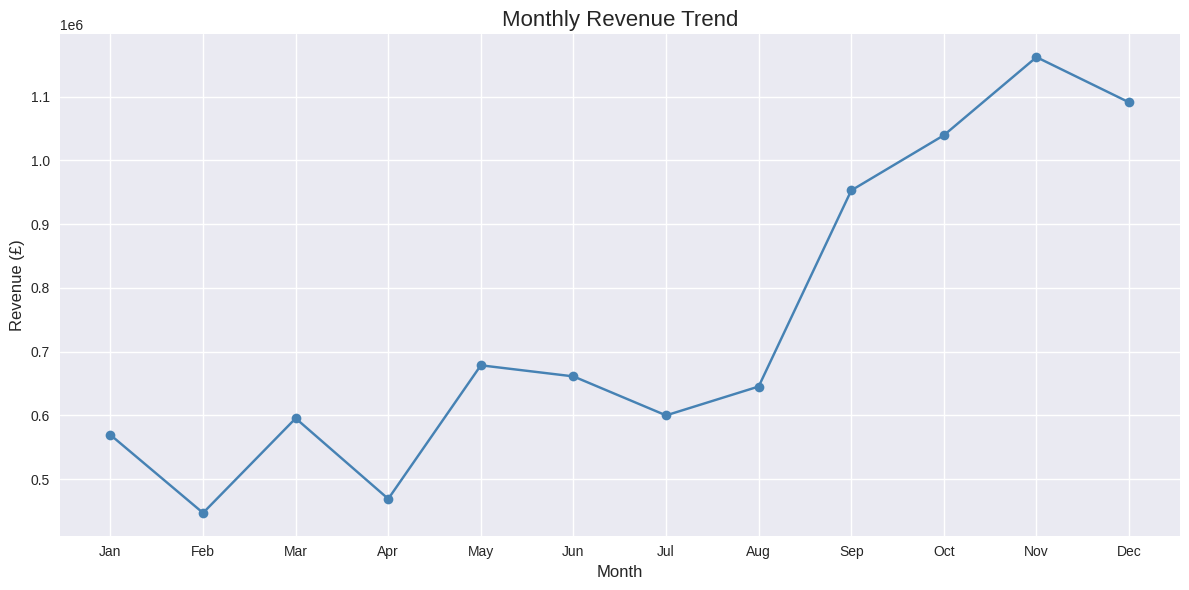

In [23]:
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', color='steelblue', marker='o')
plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

Sales peak in November, most likely due to Black Friday and early Christmas shopping. Revenue builds steadily from August through November as customers begin holiday spending. February is the slowest month, which makes sense as people tend to pull back after the holidays.

# **Who are our most valuable repeat buyers? (RFM Analysis)**

RFM analysis groups customers based on three simple behaviors: how recently they made a purchase (Recency), how often they buy (Frequency), and how much money they spend (Monetary value). It helps businesses quickly spot their most valuable customers, as well as those who haven’t purchased in a while and may be at risk of leaving.

In [34]:
# Reference date - day after last invoice
reference_date = df['InvoiceDate'].max() + timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [35]:
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('Revenue', 'sum')
).reset_index()

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [36]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0     12346.0      326          1  77183.60       1       1       4       114
1     12347.0        2          7   4310.00       4       4       4       444
2     12348.0       75          4   1797.24       2       3       4       234
3     12349.0       19          1   1757.55       3       1       4       314
4     12350.0      310          1    334.40       1       1       2       112


In [37]:
def rfm_segment(score):
    if score == '444':
        return 'Champion'
    elif score[0] in ['3','4'] and score[1] in ['3','4']:
        return 'Loyal Customer'
    elif score[0] == '4' and score[1] == '1':
        return 'New Customer'
    elif score[0] in ['1','2'] and score[1] in ['3','4']:
        return 'At Risk'
    else:
        return 'Lost/Inactive'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)
print(rfm['Segment'].value_counts())

Segment
Lost/Inactive     2095
Loyal Customer    1034
At Risk            646
Champion           489
New Customer        75
Name: count, dtype: int64


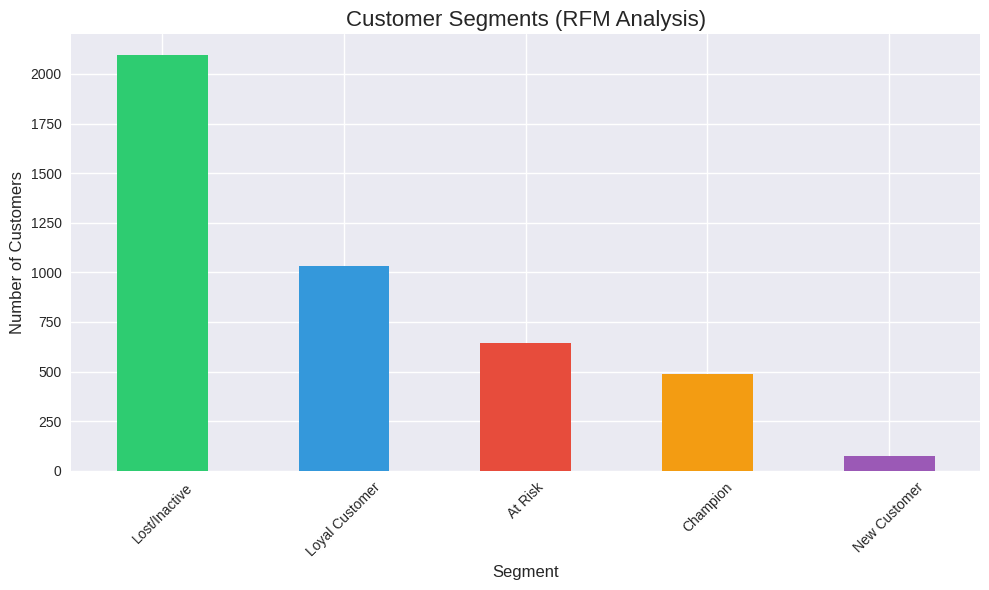

In [38]:
plt.figure(figsize=(10,6))
rfm['Segment'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'])
plt.title('Customer Segments (RFM Analysis)', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Half of the customers are either inactive or have been lost, which signals a big opportunity to bring them back through re-engagement efforts. At the same time, the 489 “Champion” customers stand out as top loyal users and should be prioritized with rewards to keep them engaged and strengthen their loyalty.

# **Which products have the highest return rate?**

In [41]:
df_raw = pd.read_excel('/content/drive/MyDrive/Projects/Online Retail.xlsx')
cancelled = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')]

return_rate = cancelled.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)
print(return_rate)

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Manual                                  4066
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
Name: Quantity, dtype: int64


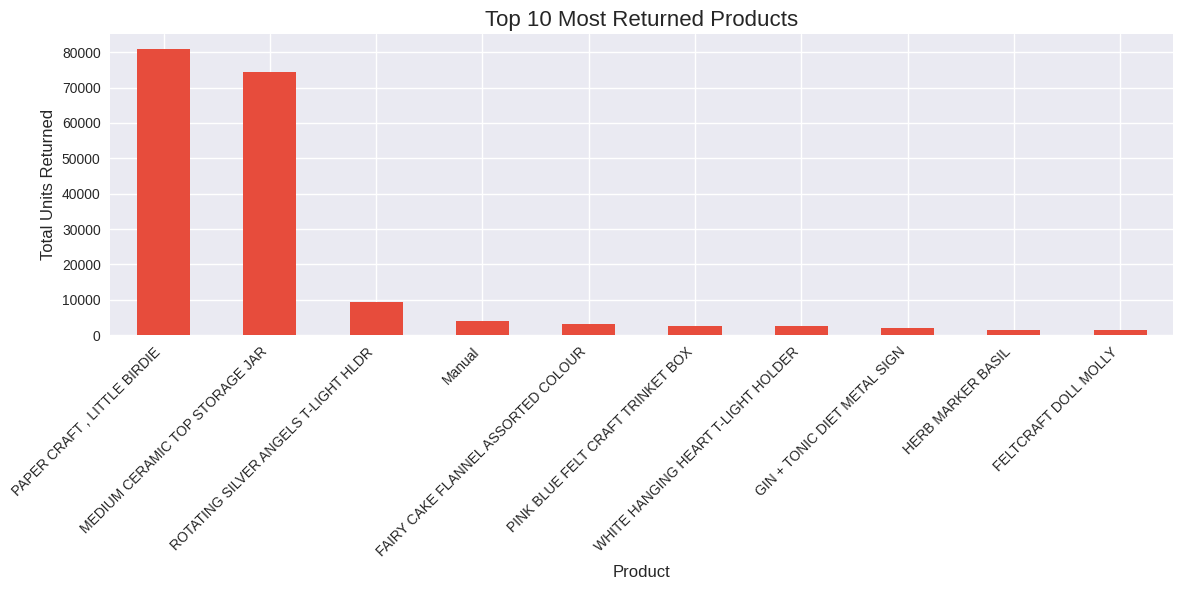

In [42]:
plt.figure(figsize=(12,6))
return_rate.plot(kind='bar', color='#e74c3c')
plt.title('Top 10 Most Returned Products', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Units Returned', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

PAPER CRAFT LITTLE BIRDIE stands out with the highest return volume by a wide margin, which is interesting because it is also the top revenue-generating product. This could indicate that a large bulk order was placed and later canceled.

MEDIUM CERAMIC TOP STORAGE JAR also has an unusually high number of returns. Together, these patterns suggest it’s important to look more closely at whether the returns are coming from a few large order cancellations or from ongoing issues with product quality or customer satisfaction.

# **How does average order value change over time?**

In [43]:
# Calculate revenue per invoice first
aov = df.groupby(['Month', 'InvoiceNo'])['Revenue'].sum().reset_index()

# Then average per month
aov = aov.groupby('Month')['Revenue'].mean().reset_index()
aov.columns = ['Month', 'AOV']

print(aov)

    Month         AOV
0       1  576.945329
1       2  448.033417
2       3  450.795428
3       4  408.355406
4       5  436.395215
5       6  474.668837
6       7  450.857258
7       8  503.781343
8       9  542.618669
9      10  538.786309
10     11  437.102099
11     12  500.875427


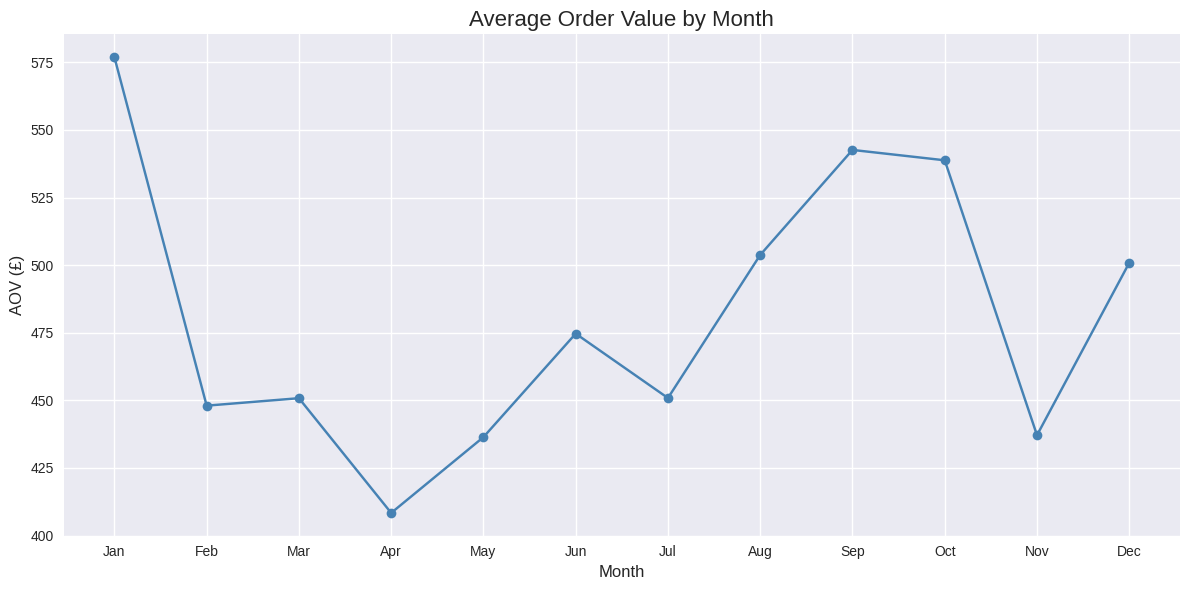

In [44]:
plt.figure(figsize=(12,6))
plt.plot(aov['Month'], aov['AOV'], color='steelblue', marker='o')
plt.title('Average Order Value by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('AOV (£)', fontsize=12)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

Average order value is highest in January at around £577, then gradually falls to its lowest point in April (about £408). After that, it steadily picks up again through September and October. What stands out is November despite being the top revenue month, AOV actually drops. That likely means people are placing more orders during Black Friday, but spending less per order because of all the discounts. By December, AOV bounces back to roughly £500.

In [45]:
df.to_csv('/content/drive/MyDrive/Projects/online_retail_cleaned.csv', index=False)
print("✅ CSV saved!")

✅ CSV saved!
